# EDA - dane pogodowe 
## 1. Cel i zakres

Analiza dotyczy danych meteorologicznych powiązanych z pomiarami CH4, objemuje zmienne pogodowe.

## 2. Opis zbioru danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dane = pd.read_csv("wszystkie_miasta_CH4.csv")
dane["Data"] = pd.to_datetime(dane["Data"])

C:\Users\fagata\AppData\Local\Temp\ipykernel_6448\1300372358.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  dane = pd.read_csv("wszystkie_miasta_CH4.csv")


In [3]:
dane.head()

,Data,Rok,Miesiac,Sezon,lon_pomiaru,lat_pomiaru,odleglosc_m,CH4_column_volume_mixing_ratio_dry_air,CO_column_number_density,tropospheric_HCHO_column_number_density,...,predkosc_wiatru_min,predkosc_wiatru_max,surface_pressure_mean,surface_pressure_min,surface_pressure_max,total_precipitation_hourly_sum,kierunek_wiatru_sredni,folder,_zrodlowy_plik,tropospheric_NO2_column_number_density
0,2019-02-05,2019,2,ZIMA,17.386892,51.390334,23641.706381,1813.597669,NaN,NaN,...,2.333672,3.568662,101350.538411,101229.667969,101553.113281,0.000049,208.242915,bogdaj_uciechow,bogdaj_uciechowch4.csv,NaN
1,2019-02-05,2019,2,ZIMA,17.449774,51.390334,20607.469992,1811.608330,NaN,NaN,...,2.333672,3.568662,101350.538411,101229.667969,101553.113281,0.000049,208.242915,bogdaj_uciechow,bogdaj_uciechowch4.csv,NaN
2,2019-02-05,2019,2,ZIMA,17.512656,51.327452,24481.747060,1815.490491,NaN,NaN,...,2.333672,3.568662,101350.538411,101229.667969,101553.113281,0.000049,208.242915,bogdaj_uciechow,bogdaj_uciechowch4.csv,NaN
3,2019-02-05,2019,2,ZIMA,17.512656,51.390334,18127.407415,1810.784421,NaN,NaN,...,2.333672,3.568662,101350.538411,101229.667969,101553.113281,0.000049,208.242915,bogdaj_uciechow,bogdaj_uciechowch4.csv,NaN
4,2019-02-05,2019,2,ZIMA,17.575539,51.327452,23268.202837,1817.142691,NaN,NaN,...,2.333672,3.568662,101350.538411,101229.667969,101553.113281,0.000049,208.242915,bogdaj_uciechow,bogdaj_uciechowch4.csv,NaN


In [4]:
dane.shape

(192146, 34)

In [5]:
dane.columns

Index(['Data', 'Rok', 'Miesiac', 'Sezon', 'lon_pomiaru', 'lat_pomiaru',
       'odleglosc_m', 'CH4_column_volume_mixing_ratio_dry_air',
       'CO_column_number_density', 'tropospheric_HCHO_column_number_density',
       'NO2_column_number_density', 'O3_column_number_density',
       'SO2_column_number_density', 'miejsce', 'temperature_2m_mean',
       'temperature_2m_min', 'temperature_2m_max',
       'dewpoint_temperature_2m_mean', 'dewpoint_temperature_2m_min',
       'dewpoint_temperature_2m_max', 'wilgotnosc_wzgledna_mean',
       'wilgotnosc_wzgledna_min', 'wilgotnosc_wzgledna_max',
       'predkosc_wiatru_mean', 'predkosc_wiatru_min', 'predkosc_wiatru_max',
       'surface_pressure_mean', 'surface_pressure_min', 'surface_pressure_max',
       'total_precipitation_hourly_sum', 'kierunek_wiatru_sredni', 'folder',
       '_zrodlowy_plik', 'tropospheric_NO2_column_number_density'],
      dtype='object')

In [6]:
dane['miejsce'].unique()

array(['bogdaj-uciechow-czeszow', 'hurko', 'jaroslaw', 'jodlowka',
       'koscian-bronsko', 'krasne', 'mackowice', 'radlin', 'roztoki',
       'szczepanow', 'tarnow-ii', 'tuliglowy', 'wielichowo', 'wilkow',
       'zalesie', 'zolynia', 'zuchlow', 'zurawica', nan], dtype=object)

In [7]:
dane['Sezon'].unique()

array(['ZIMA', 'LATO'], dtype=object)

Pierwszym etapem analizy jest wczytanie zbioru, który obejmuje 192 146 wierszy, 34 kolumny. Każdy wiersz to pomiar satelitarny (piksel ze współrzędnymi) z danych ERA5 dla danego dnia. Zbiór jest stosunkowo duży, obejmuje również kolumny niepotrzebne w dalszej analizie, a także takie wymagające czyszczenia.

Dane obejmują 18 lokalizacji i dwa sezony: lato oraz zimę. 

## 3. Czyszczenie danych

In [8]:
ile = dane.duplicated().sum()
ile

np.int64(0)

In [9]:
klucz = ["Data", "lon_pomiaru", "lat_pomiaru"]
ile_klucz = dane.duplicated(subset=klucz).sum()
print(f"Duplikaty (po dacie + lokalizacji): {ile_klucz}")

Duplikaty (po dacie + lokalizacji): 69446


In [10]:
dane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192146 entries, 0 to 192145
Data columns (total 34 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   Data                                     192146 non-null  datetime64[ns]
 1   Rok                                      192146 non-null  int64         
 2   Miesiac                                  192146 non-null  int64         
 3   Sezon                                    192146 non-null  object        
 4   lon_pomiaru                              192146 non-null  float64       
 5   lat_pomiaru                              192146 non-null  float64       
 6   odleglosc_m                              192146 non-null  float64       
 7   CH4_column_volume_mixing_ratio_dry_air   192146 non-null  float64       
 8   CO_column_number_density                 1977 non-null    float64       
 9   tropospheric_HCHO_column_n

In [11]:
braki = dane.isna().sum().sort_values(ascending=False)
braki_proc = (dane.isna().mean() * 100).sort_values(ascending=False)
podsumowanie_brakow = pd.DataFrame({"liczba_brakow": braki, "procent": braki_proc})
podsumowanie_brakow[podsumowanie_brakow["liczba_brakow"] > 0]

,liczba_brakow,procent
O3_column_number_density,192146,100.000000
tropospheric_NO2_column_number_density,191831,99.836062
NO2_column_number_density,191004,99.405660
CO_column_number_density,190169,98.971095
tropospheric_HCHO_column_number_density,187497,97.580486
SO2_column_number_density,184917,96.237757
miejsce,26490,13.786392
surface_pressure_mean,9116,4.744309
predkosc_wiatru_max,9116,4.744309
temperature_2m_min,9116,4.744309


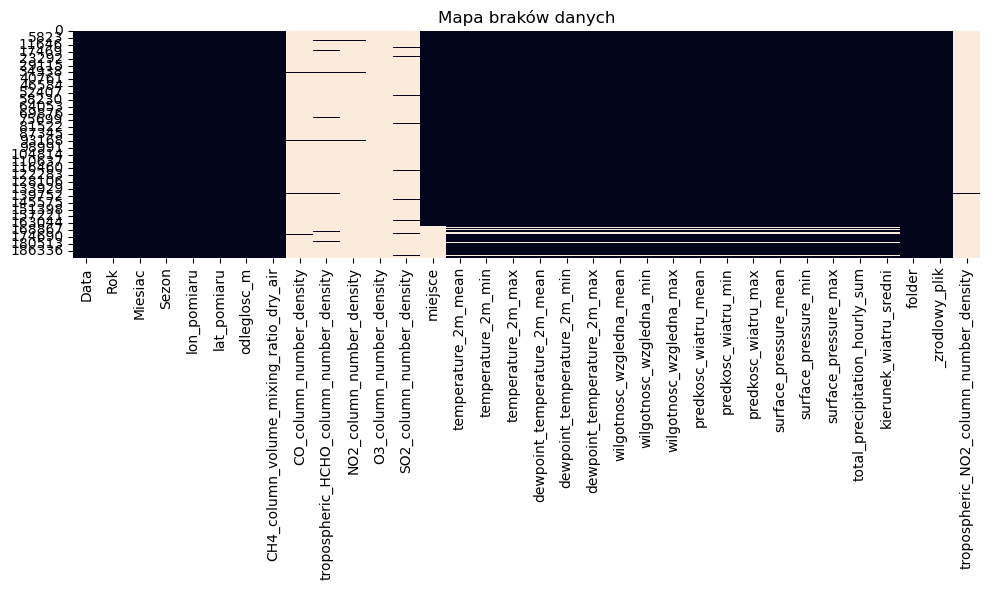

In [12]:
#wizualnie 
plt.figure(figsize=(10, 6))
sns.heatmap(dane.isna(), cbar=False)
plt.title("Mapa braków danych")
plt.tight_layout()
plt.show()

Brak duplikatów całych wierszy, istnieją jednak duplikaty po kluczu: dacie i miejscu.

Barki danych występują, jest ich szczególnie dużo dla zmiennych gazowych. Te kolumny zostana pominięte w dalszych analizach. Dużymi brakami charakteryzuje się też zmienna 'miejsce', co prawdopodobnie wynika z braku przypisanej stacji (za daleko). Dla wszytskich zmiennych pogodowych braki są jednakowe: 4.74%, 9116 wuerszy - konkretne dni/stacje nie mają zarejestrowanych danych. Ponieważ jest to mniej niż 5%, można bez ryzyka pominąc te wiersze w dalszych analizach. 

In [13]:
kolumny_K = ['temperature_2m_mean', 'temperature_2m_min', 'temperature_2m_max',
             'dewpoint_temperature_2m_mean', 'dewpoint_temperature_2m_min', 'dewpoint_temperature_2m_max']

dane[kolumny_K].describe()

,temperature_2m_mean,temperature_2m_min,temperature_2m_max,dewpoint_temperature_2m_mean,dewpoint_temperature_2m_min,dewpoint_temperature_2m_max
count,183030.000000,183030.000000,183030.000000,183030.000000,183030.000000,183030.000000
mean,285.797479,279.882784,291.476253,278.475086,275.971739,281.206294
std,10.198895,9.324600,10.360719,8.662411,8.918444,8.626714
min,259.183982,254.797684,262.292465,254.747028,251.289841,256.811996
25%,276.662022,271.417496,282.699585,271.409013,268.495407,273.999832
50%,284.310218,279.288544,289.945892,277.945096,275.439484,280.672058
75%,295.702653,288.919647,301.155579,286.357066,283.867386,289.066116
max,305.132261,297.944077,312.899353,294.821911,293.590225,298.537369


In [14]:
for k in kolumny_K:
    dane[k + '_C'] = dane[k] - 273.15

In [15]:
dane.columns

Index(['Data', 'Rok', 'Miesiac', 'Sezon', 'lon_pomiaru', 'lat_pomiaru',
       'odleglosc_m', 'CH4_column_volume_mixing_ratio_dry_air',
       'CO_column_number_density', 'tropospheric_HCHO_column_number_density',
       'NO2_column_number_density', 'O3_column_number_density',
       'SO2_column_number_density', 'miejsce', 'temperature_2m_mean',
       'temperature_2m_min', 'temperature_2m_max',
       'dewpoint_temperature_2m_mean', 'dewpoint_temperature_2m_min',
       'dewpoint_temperature_2m_max', 'wilgotnosc_wzgledna_mean',
       'wilgotnosc_wzgledna_min', 'wilgotnosc_wzgledna_max',
       'predkosc_wiatru_mean', 'predkosc_wiatru_min', 'predkosc_wiatru_max',
       'surface_pressure_mean', 'surface_pressure_min', 'surface_pressure_max',
       'total_precipitation_hourly_sum', 'kierunek_wiatru_sredni', 'folder',
       '_zrodlowy_plik', 'tropospheric_NO2_column_number_density',
       'temperature_2m_mean_C', 'temperature_2m_min_C', 'temperature_2m_max_C',
       'dewpoint_temper

In [16]:
# kolumny
kolumny_pogoda = [
    'temperature_2m_mean_C', 'temperature_2m_min_C', 'temperature_2m_max_C',
             'dewpoint_temperature_2m_mean_C', 'dewpoint_temperature_2m_min_C', 'dewpoint_temperature_2m_max_C',
    "wilgotnosc_wzgledna_mean", "wilgotnosc_wzgledna_min", "wilgotnosc_wzgledna_max",
    "predkosc_wiatru_mean", "predkosc_wiatru_min", "predkosc_wiatru_max",
    "surface_pressure_mean", "surface_pressure_min", "surface_pressure_max",
    "total_precipitation_hourly_sum", "kierunek_wiatru_sredni",
]
target = "CH4_column_volume_mixing_ratio_dry_air"

Kolumny zawierające informacje o temperaturze były podane w kelwinach, konieczna była konwersja do stopni celsjusza. Zakresy po konwersji wyglądają realistycznie dla klimatu.

In [17]:
dane[kolumny_pogoda + [target]].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m_mean_C,183030.0,12.647479,10.198895,-1.396602e+01,3.512022e+00,11.160218,22.552653,31.982261
temperature_2m_min_C,183030.0,6.732784,9.324600,-1.835232e+01,-1.732504e+00,6.138544,15.769647,24.794077
temperature_2m_max_C,183030.0,18.326253,10.360719,-1.085753e+01,9.549585e+00,16.795892,28.005579,39.749353
dewpoint_temperature_2m_mean_C,183030.0,5.325086,8.662411,-1.840297e+01,-1.740987e+00,4.795096,13.207066,21.671911
dewpoint_temperature_2m_min_C,183030.0,2.821739,8.918444,-2.186016e+01,-4.654593e+00,2.289484,10.717386,20.440225
dewpoint_temperature_2m_max_C,183030.0,8.056294,8.626714,-1.633800e+01,8.498322e-01,7.522058,15.916116,25.387369
wilgotnosc_wzgledna_mean,183030.0,64.252820,11.209603,3.542265e+01,5.587451e+01,64.620637,72.450482,94.530911
wilgotnosc_wzgledna_min,183030.0,44.962355,11.601844,1.375410e+01,3.683296e+01,43.297426,52.162347,86.155384
wilgotnosc_wzgledna_max,183030.0,84.168178,10.019236,5.269864e+01,7.814226e+01,86.551175,91.736061,100.012711
predkosc_wiatru_mean,183030.0,2.661086,0.885700,7.040233e-01,1.984532e+00,2.602137,3.214058,7.199651


Statystyki opisowe są sensowene i mają realistyczne zakresy - brak ewidentnych błędów pomiarowych.

In [18]:
def outliery(df, kol):
    q1, q3 = df[kol].quantile([0.25, 0.75])
    iqr = q3 - q1
    dolna, gorna = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    maska = (df[kol] < dolna) | (df[kol] > gorna)
    return maska.sum(), dolna, gorna
 
for kol in kolumny_pogoda + [target]:
    n, dolna, gorna = outliery(dane, kol)
    print(f"{kol:45s} outlierów: {n:5d}  (zakres OK: {dolna:.2f} .. {gorna:.2f})")

temperature_2m_mean_C                         outlierów:     0  (zakres OK: -25.05 .. 51.11)
temperature_2m_min_C                          outlierów:     0  (zakres OK: -27.99 .. 42.02)
temperature_2m_max_C                          outlierów:     0  (zakres OK: -18.13 .. 55.69)
dewpoint_temperature_2m_mean_C                outlierów:     0  (zakres OK: -24.16 .. 35.63)
dewpoint_temperature_2m_min_C                 outlierów:     0  (zakres OK: -27.71 .. 33.78)
dewpoint_temperature_2m_max_C                 outlierów:     0  (zakres OK: -21.75 .. 38.52)
wilgotnosc_wzgledna_mean                      outlierów:     0  (zakres OK: 31.01 .. 97.31)
wilgotnosc_wzgledna_min                       outlierów:  2668  (zakres OK: 13.84 .. 75.16)
wilgotnosc_wzgledna_max                       outlierów:  1827  (zakres OK: 57.75 .. 112.13)
predkosc_wiatru_mean                          outlierów:  1452  (zakres OK: 0.14 .. 5.06)
predkosc_wiatru_min                           outlierów:   599  (zakres OK:

Obserwacje związane z outlierami:
- zmienne temperaturowe nie zawierają outlierów. Może to jednak być błędne, ponieważ dane są podzielone na dwa sezony, a tu dane z zimy i lata są pomieszane. 
- opad to około 20% wierszy z wartościami odstającymi. Jest to raczej naturalna cecha danyhc meteorologicznych, większośc dni to raczej brak opadów i kilka dni z realnymi opadami
- prędkość wiatru, około 1.5% outlierów
- ciśnienie: tylko 33 outliery, co czyni tę zmienną stabilną
- metan: 1218 wartości odstających

## 4. Rozkłady zmiennych

IndexError: index 16 is out of bounds for axis 0 with size 16

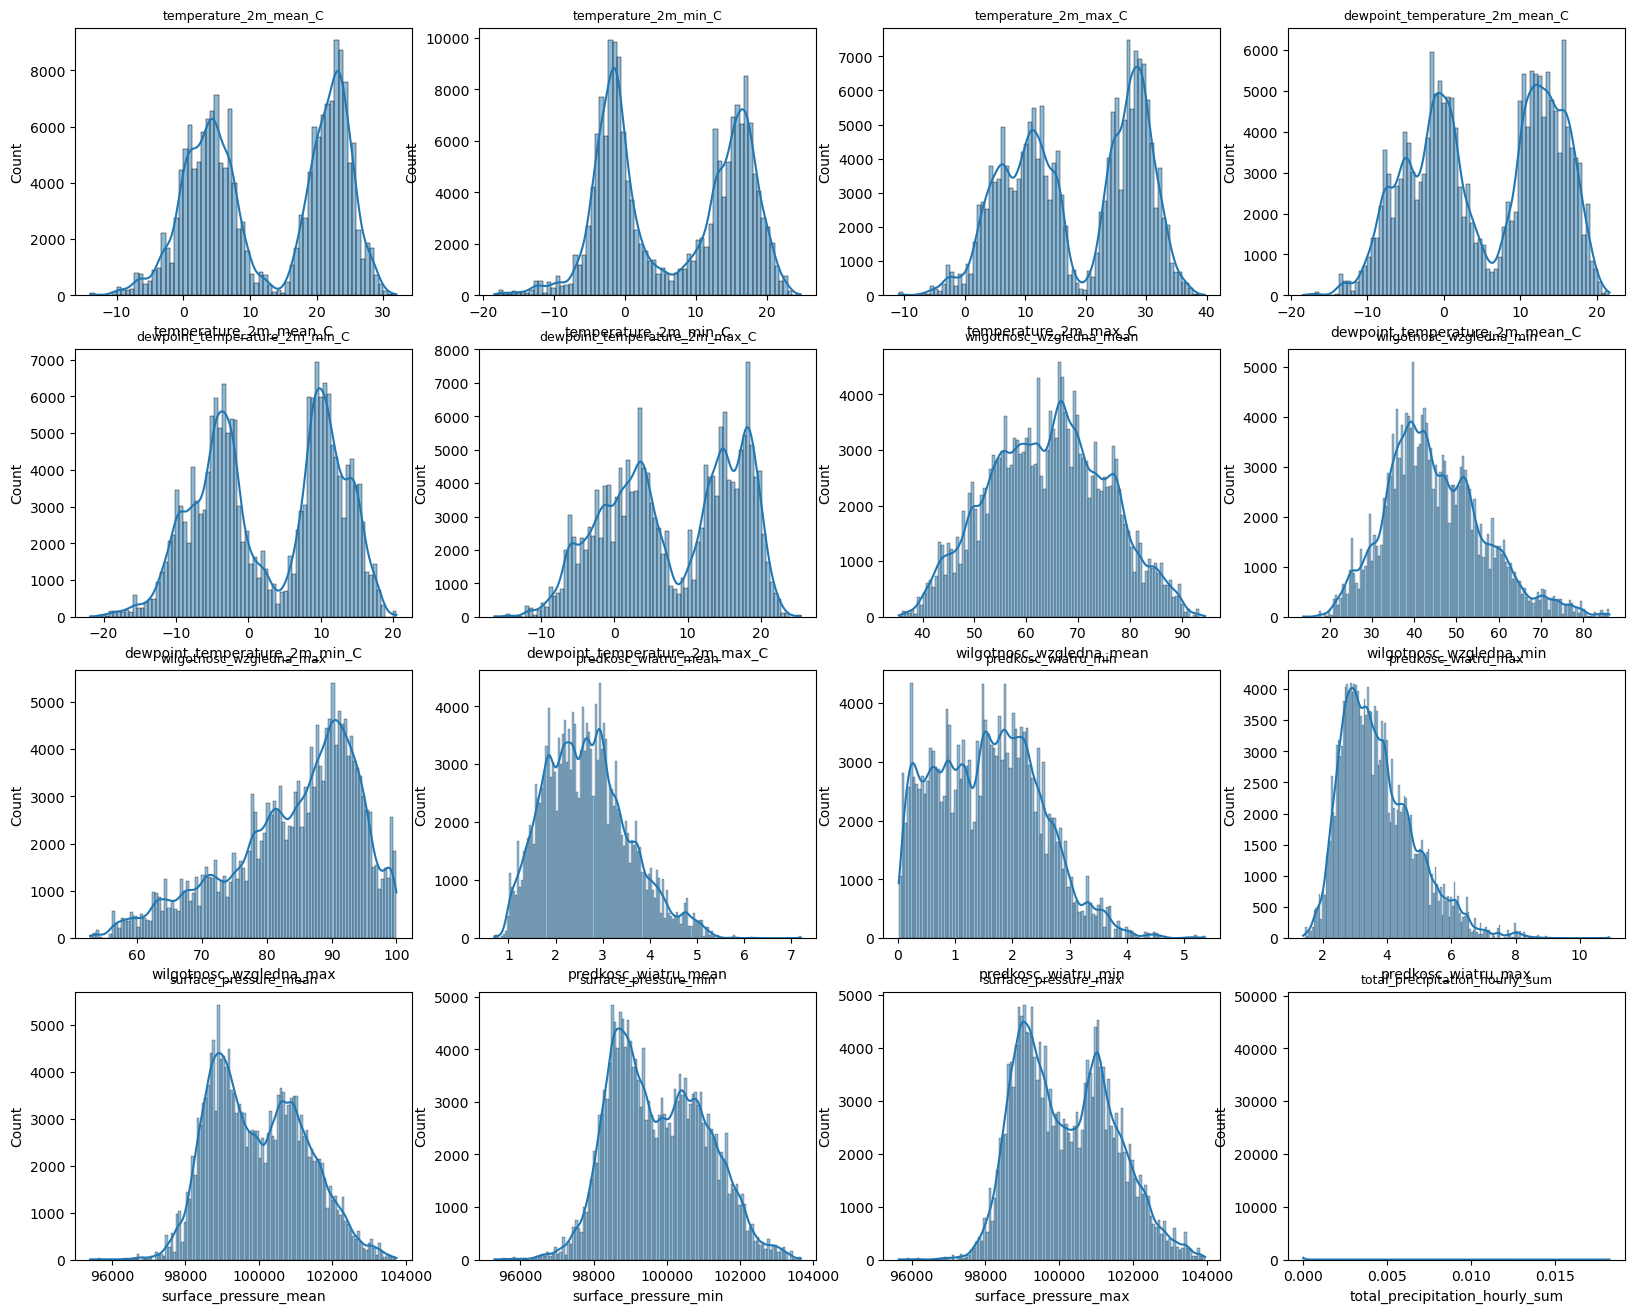

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, kol in enumerate(kolumny_pogoda + [target]):
    sns.histplot(dane[kol].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(kol, fontsize=9)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Histogramy wszytskihc zmiennych pogodowych są wyraźnie bimodalne: ld atemperatury, punktu rosy i ciśnienia. Ma to związek z wystepowaniem dwóch sezonów: lata i zimy, które różnią się charakterystyką zmiennych pogodowych. Wilgotnośc i prędkość wiatru mają rozkłady bardziej jednomodlane, zbliżone do normalnego, z lekkim skosem. Wartości metanu mają rozkład jednomoodalny, zbliżony do normalnego, z prawostronnym ogonem.

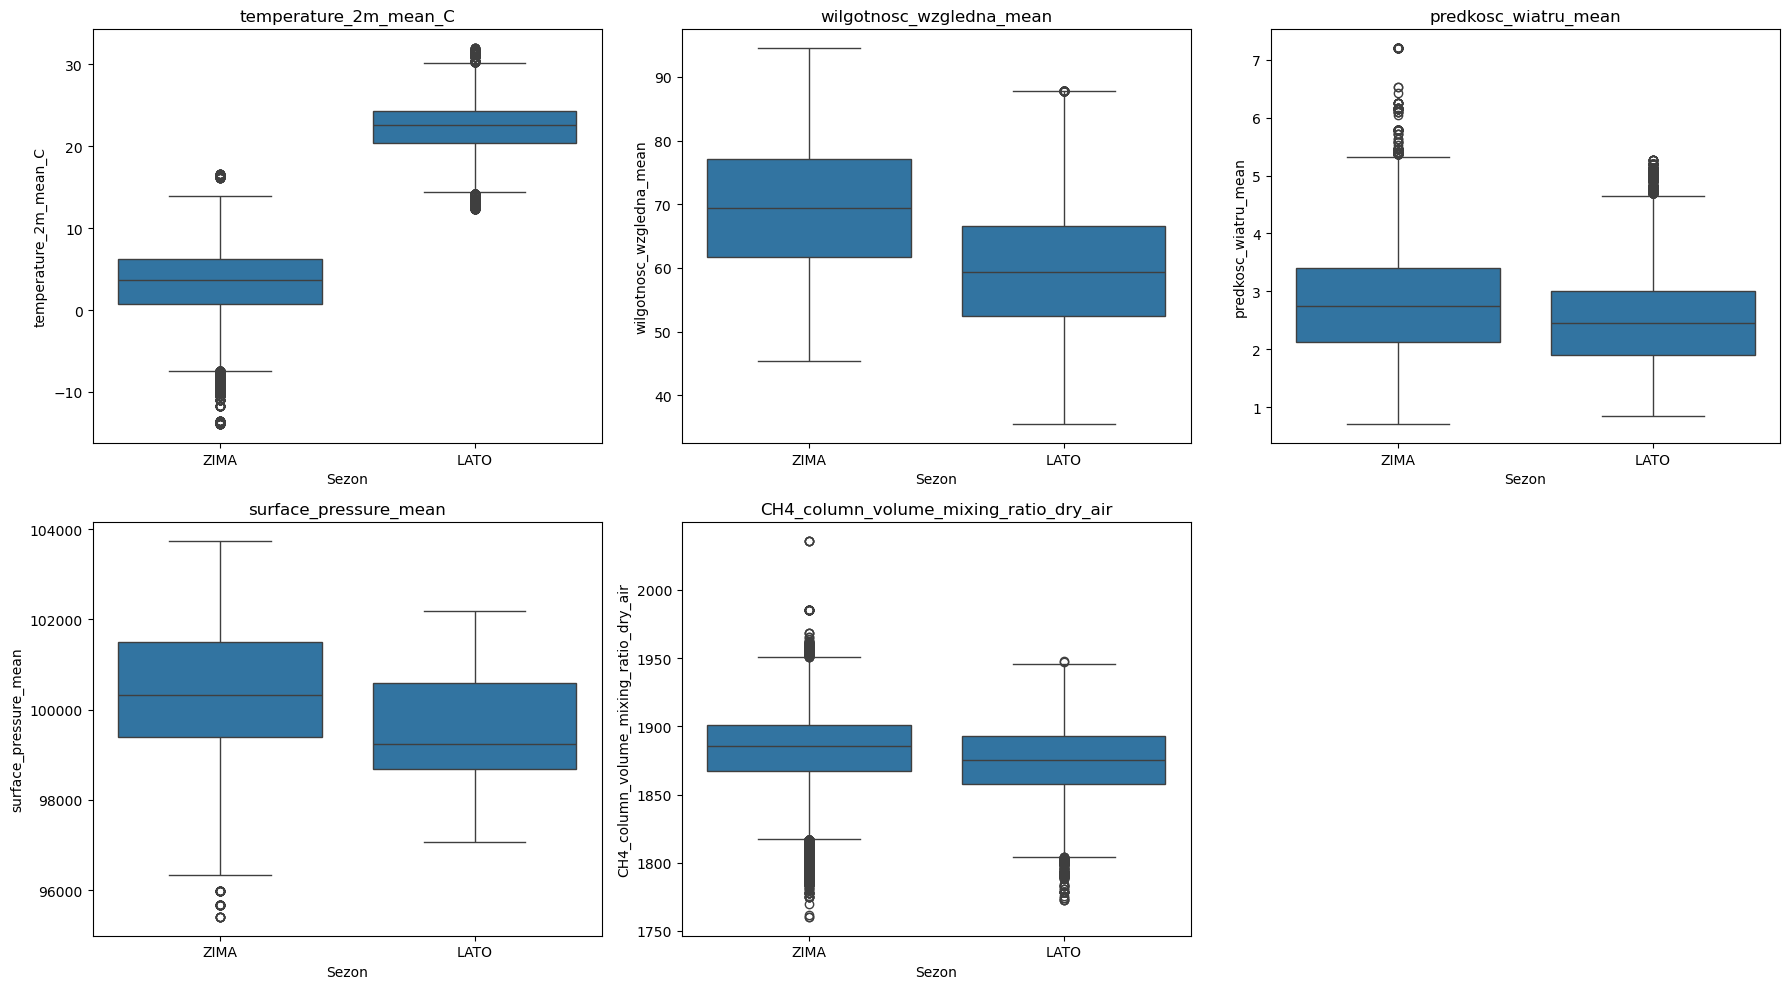

In [20]:
# BOXPLOTY WG SEZONU
kolumny_do_boxplot = ["temperature_2m_mean_C", "wilgotnosc_wzgledna_mean",
                      "predkosc_wiatru_mean", "surface_pressure_mean", target]
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, kol in enumerate(kolumny_do_boxplot):
    sns.boxplot(data=dane, x="Sezon", y=kol, ax=axes[i])
    axes[i].set_title(kol)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Widać, że charakterystyka zmiennyhc pogodowych zmienia się znacząco (szczególnie temperatura, wilgotność) w zależności od sezonu. Punkty z zimy mają wyżej i szerzej rozłożone CH4 niż punkty z lata.

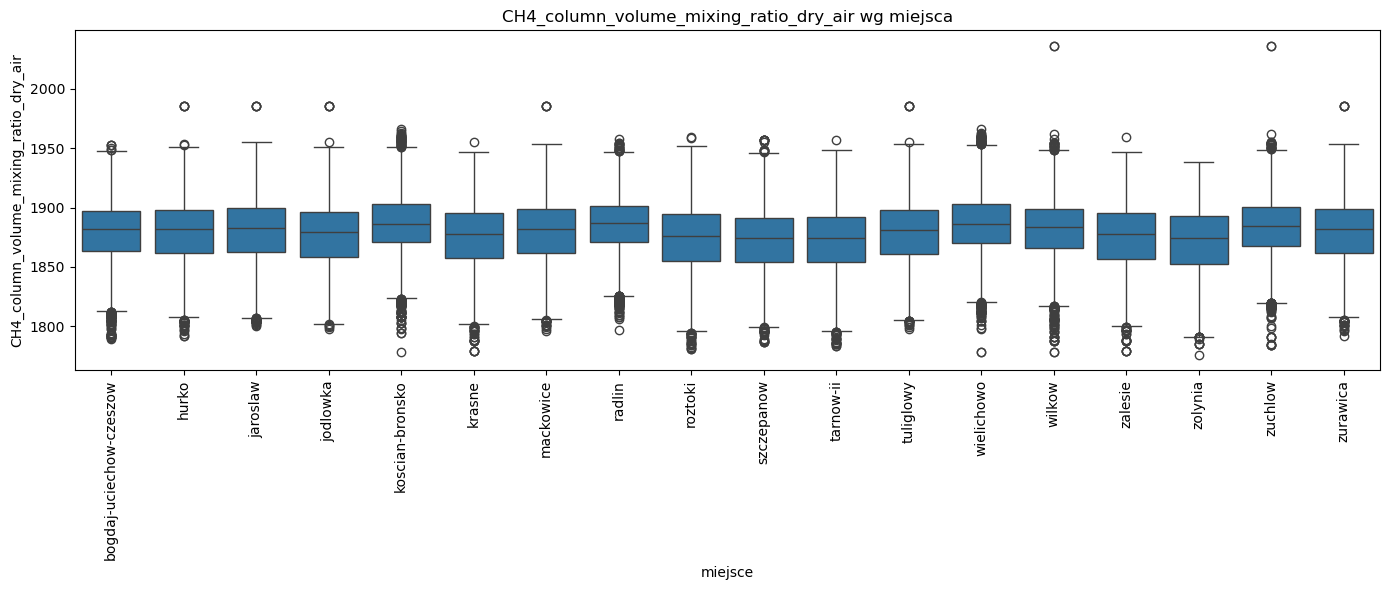

In [21]:
# BOXPLOTY WG MIEJSCA
plt.figure(figsize=(14, 6))
sns.boxplot(data=dane, x="miejsce", y=target)
plt.xticks(rotation=90)
plt.title(f"{target} wg miejsca")
plt.tight_layout()
plt.show()

Mediany boxplotów są do siebie zbliżone dla większości stacji, ae kilka znacząco odstaje liczbą oulierów (koscian-bronsko, wielichowo, wilkow, zuchlow) - e stacje mają zauważalnie więcej wysokich wartości.

In [22]:
# KORELACJE Z CH4 (Pearson + Spearman)
korelacje = pd.DataFrame({
    "pearson": [dane[target].corr(dane[k], method="pearson") for k in kolumny_pogoda],
    "spearman": [dane[target].corr(dane[k], method="spearman") for k in kolumny_pogoda],
}, index=kolumny_pogoda).sort_values("pearson", key=abs, ascending=False)
 
korelacje

,pearson,spearman
surface_pressure_min,0.201553,0.202582
temperature_2m_min_C,-0.197112,-0.210027
dewpoint_temperature_2m_mean_C,-0.196690,-0.199140
dewpoint_temperature_2m_max_C,-0.193759,-0.195954
dewpoint_temperature_2m_min_C,-0.192519,-0.192225
surface_pressure_mean,0.185448,0.186399
temperature_2m_mean_C,-0.177287,-0.183238
surface_pressure_max,0.169966,0.173303
predkosc_wiatru_max,-0.161084,-0.138252
temperature_2m_max_C,-0.160358,-0.161105


Wszytskie korelacje są słabe (mniejsze niz 0.2). Żadna pojedyncza zmienna pogodowa nie tłumaczy sensownej części zmienności CH4 w sposób liniowy. Opad to jedyna zmienna, gdzie Spearman (-0.242) jest wyraźnie silniejszy niż Pearson (-0.083), co sugeruje nieliniowa zależność. Kierunek korelacji (ujemny dla temperatury, dodatni dla ciśnienia) jest spójny z obserwacją (niższa temperatura, wyższe ciśnienie przy wyżach). 

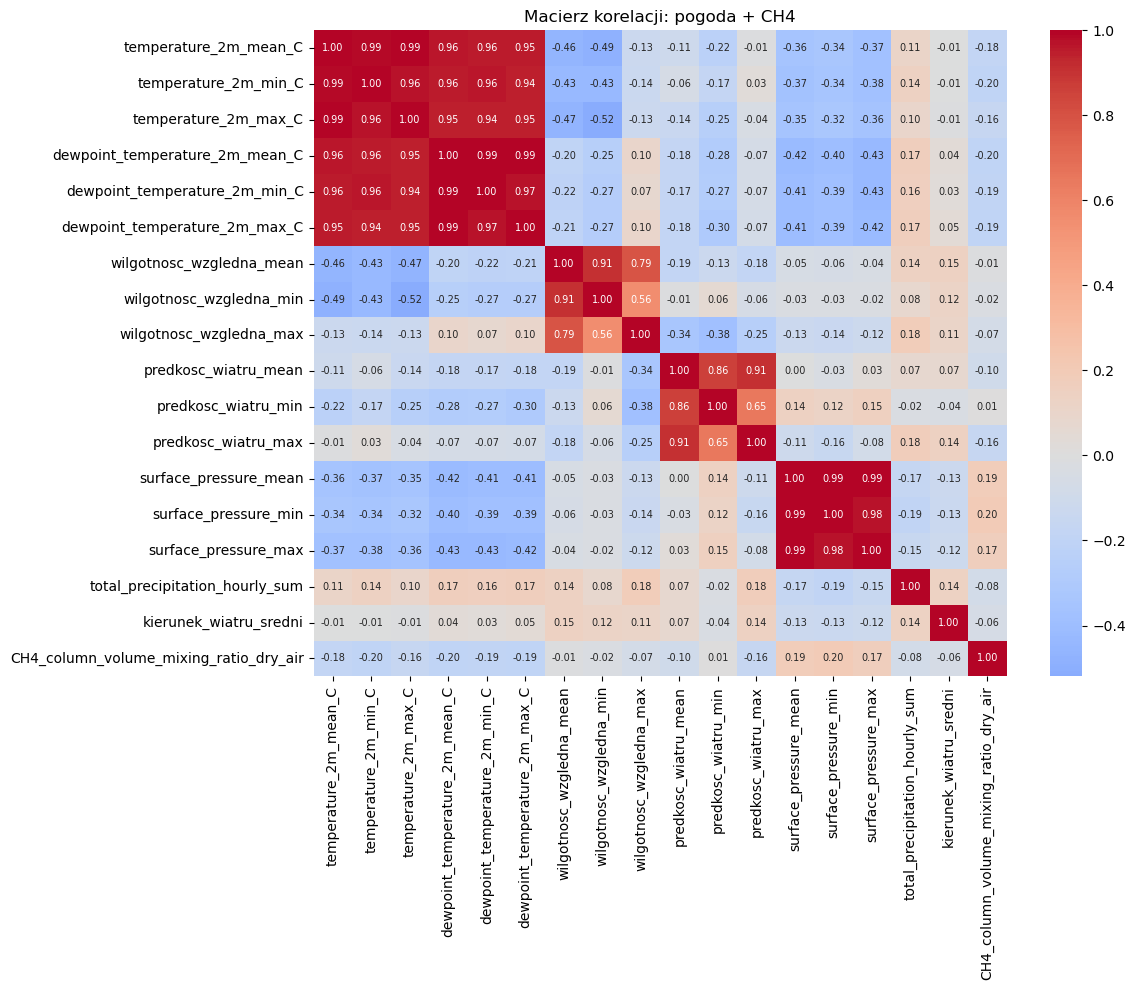

In [23]:
# MACIERZ KORELACJI (heatmapa)
plt.figure(figsize=(12, 10))
macierz = dane[kolumny_pogoda + [target]].corr()
sns.heatmap(macierz, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7})
plt.title("Macierz korelacji: pogoda + CH4")
plt.tight_layout()
plt.show()

Macierz korelacji pogoda-pogoda pokazuje silne grupy skorelowanych zmiennych: temperatura silnie skorelowana ze sobą i z punktem rosy; podobnie z ciśnieniem. Prędkość wiatru słabiej, ale nadal na poziomie 0.65-0.91. Te grupy zmiennych są praktycznie redundantne.Poza tym korelacje nie są znaczące.

In [24]:
# SPRAWDZENIE CZY BRAKI SĄ SKONCENTROWANE (wg miejsca i sezonu)
braki_wg_miejsca = dane[dane.isna().any(axis=1)]["miejsce"].value_counts()
print("Liczba wierszy z brakami wg miejsca:")
print(braki_wg_miejsca)

braki_wg_sezonu = dane[dane.isna().any(axis=1)]["Sezon"].value_counts()
print("\nLiczba wierszy z brakami wg sezonu:")
print(braki_wg_sezonu)

Liczba wierszy z brakami wg miejsca:
miejsce
radlin                     10691
szczepanow                 10157
koscian-bronsko             9930
tarnow-ii                   9809
jodlowka                    9296
krasne                      9247
tuliglowy                   9225
zalesie                     9180
jaroslaw                    9170
zolynia                     9109
zuchlow                     9037
zurawica                    8969
wielichowo                  8811
roztoki                     8778
mackowice                   8777
bogdaj-uciechow-czeszow     8661
hurko                       8639
wilkow                      8170
Name: count, dtype: int64

Liczba wierszy z brakami wg sezonu:
Sezon
ZIMA    98069
LATO    94077
Name: count, dtype: int64


In [25]:
# USUWANIE BRAKÓW (tylko po kolumnach faktycznie używanych w EDA)
przed = dane.shape[0]

dane = dane.dropna(subset=kolumny_pogoda + [target])

po = dane.shape[0]
usuniete = przed - po

print(f"Wierszy przed usunięciem braków: {przed}")
print(f"Wierszy po usunięciu braków:     {po}")
print(f"Usunięto: {usuniete} wierszy ({usuniete/przed*100:.2f}%)")

Wierszy przed usunięciem braków: 192146
Wierszy po usunięciu braków:     183030
Usunięto: 9116 wierszy (4.74%)


Sprawdzono rozkład braków danych wg miejsca pomiaru i sezonu, aby upewnić się, że braki nie są skoncentrowane w jednej lokalizacji lub porze roku (co mogłoby wypaczyć dalszą analizę po ich usunięciu). Następnie usunięto wiersze z brakami wyłącznie w kolumnach wykorzystywanych w dalszej analizie (kolumny_pogoda oraz zmienna docelowa), zachowując rekordy z brakami w kolumnach nieużywanych w EDA. 

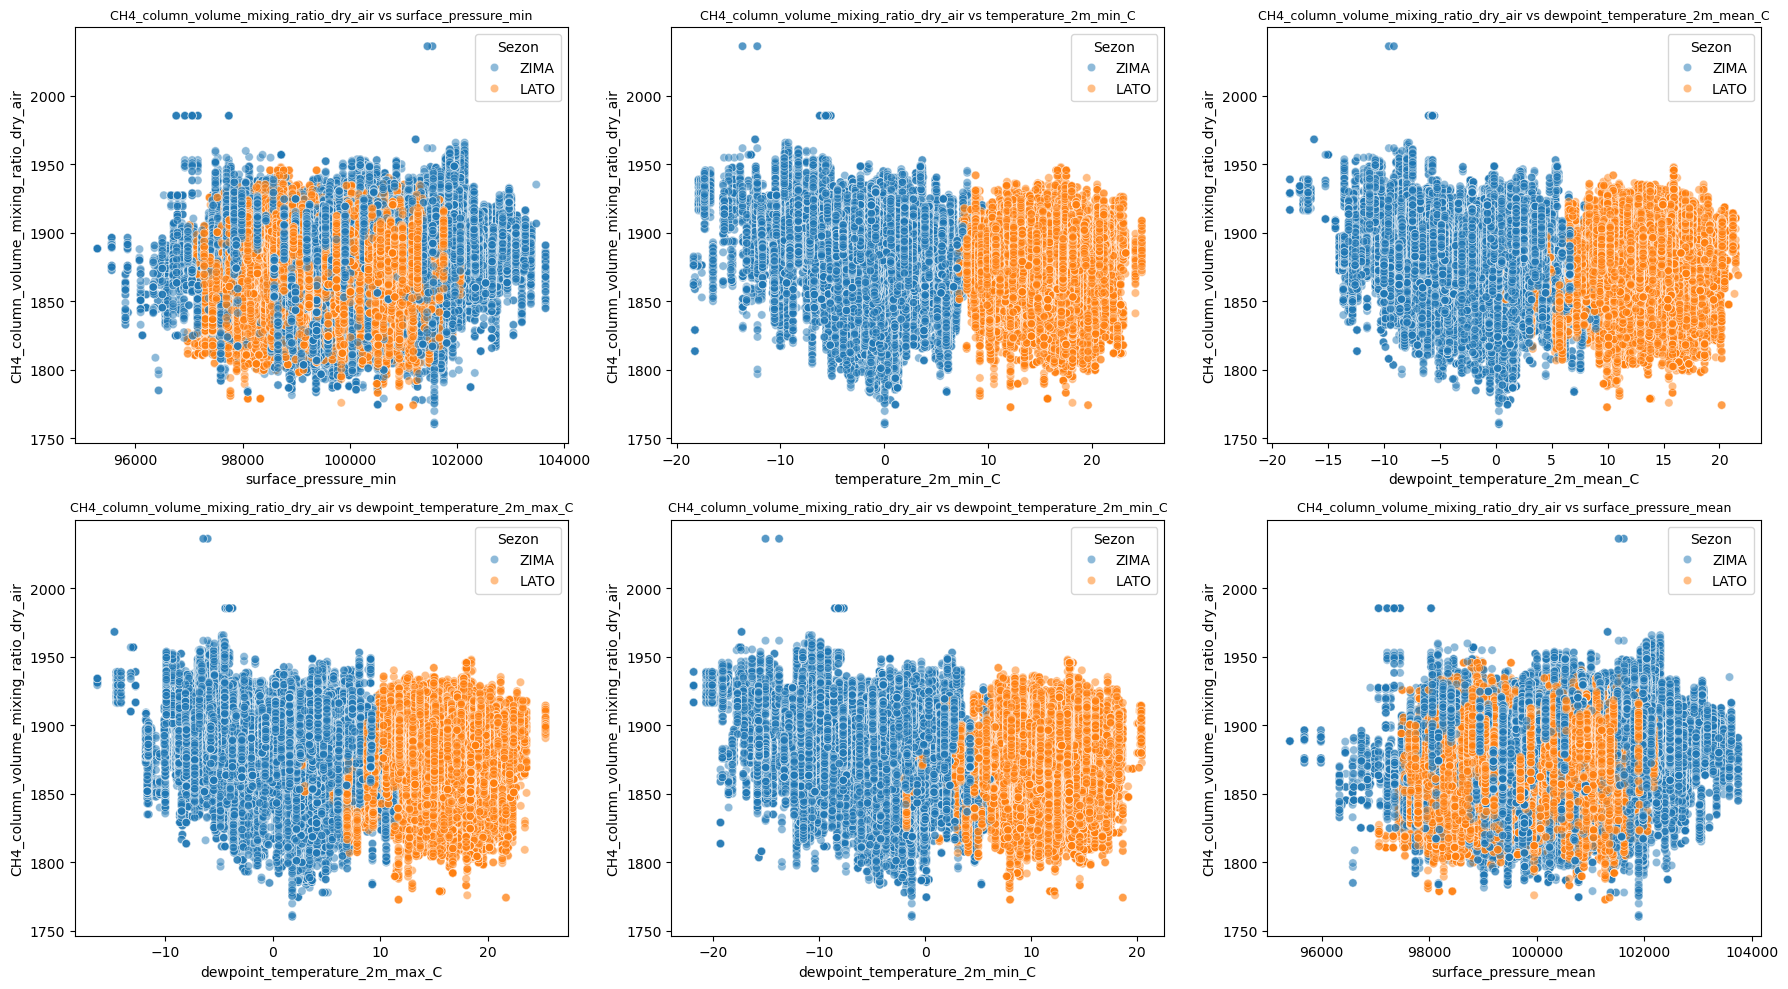

In [26]:
# SCATTERPLOTY CH4 vs POGODA (kolor = sezon)
najwazniejsze = korelacje.head(6).index.tolist()
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, kol in enumerate(najwazniejsze):
    sns.scatterplot(data=dane, x=kol, y=target, hue="Sezon", alpha=0.5, ax=axes[i])
    axes[i].set_title(f"{target} vs {kol}", fontsize=9)
plt.tight_layout()
plt.show()

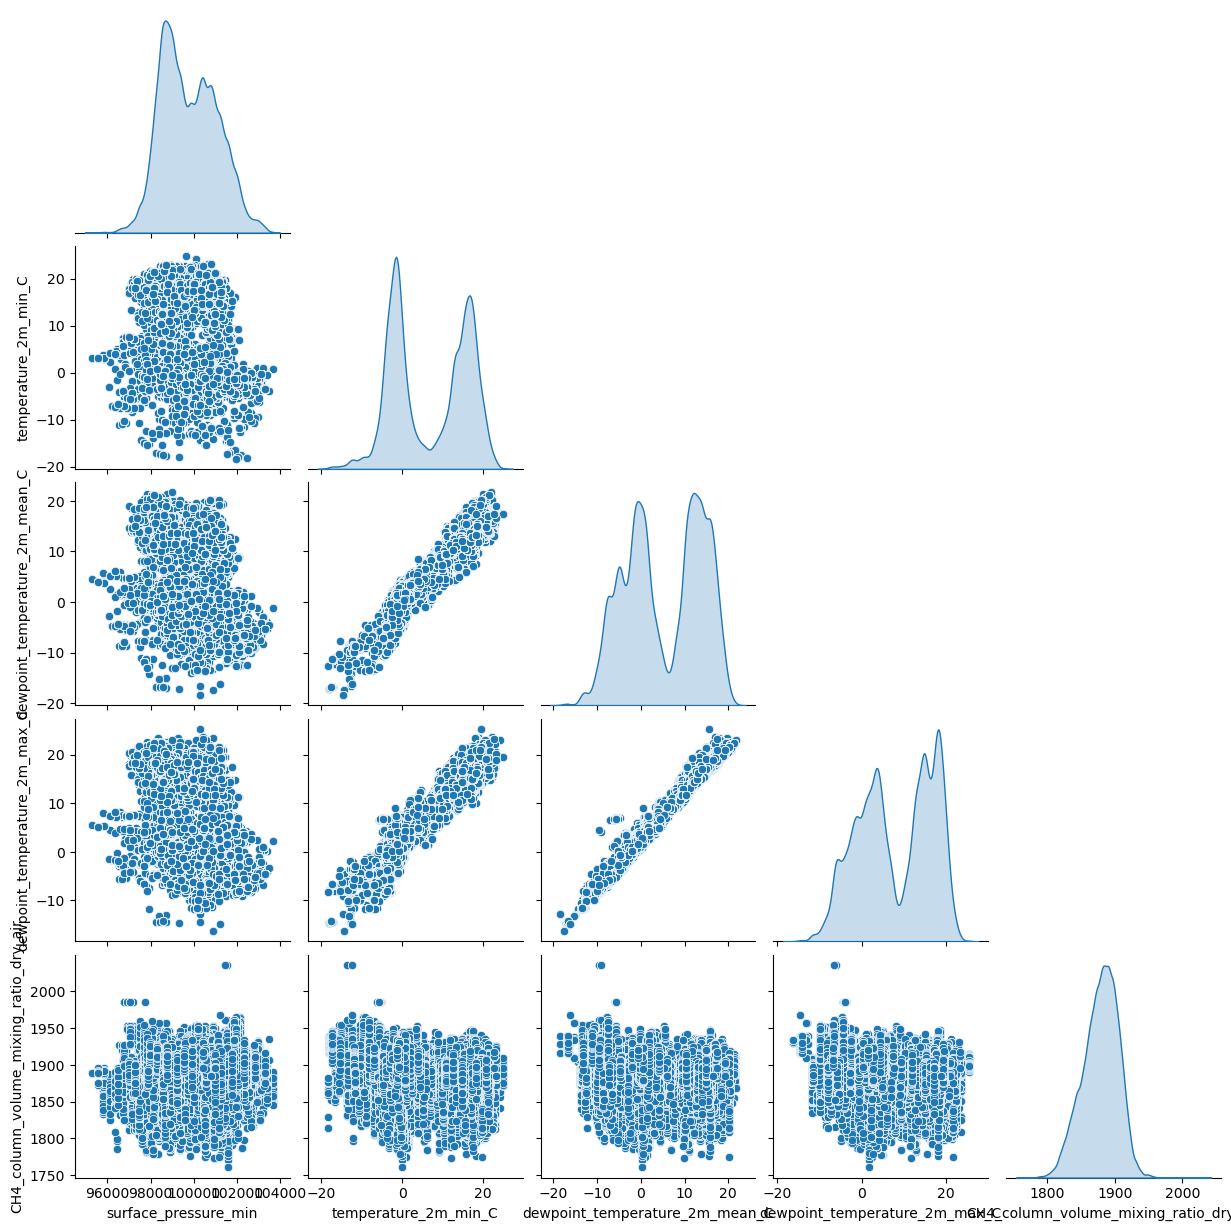

In [27]:
sns.pairplot(dane[najwazniejsze[:4] + [target]].dropna(), diag_kind="kde", corner=True)
plt.show()

Scatterploty CH4 vs 6 najmocniej skorelowanych zmiennych (kolorowane wg sezonu) potwierdzają, że zima i lato tworzą wyraźnie odseparowane chmury wzdłuż osi temperatury/punktu rosy, a nie losowo wymieszane punkty. To mocny argument za tym, że to, co widzimy jako "korelację z temperaturą", jest w dużej mierze korelacją z sezonem.
Pairplot potwierdza silną liniową zależność temperatura a punkt rosy i brak czytelnego liniowego wzorca między zmiennymi pogodowymi a CH4 na poziomie pojedynczych par zmiennych.

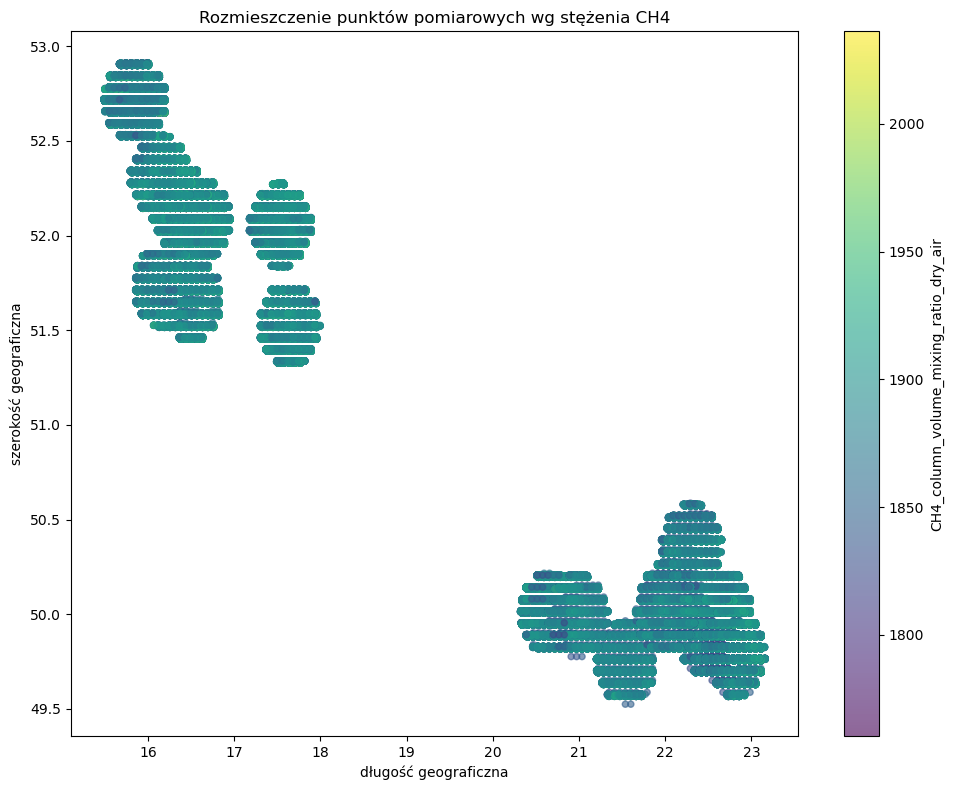

In [28]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(dane["lon_pomiaru"], dane["lat_pomiaru"],
                  c=dane[target], cmap="viridis", alpha=0.6, s=20)
plt.colorbar(sc, label=target)
plt.xlabel("długość geograficzna")
plt.ylabel("szerokość geograficzna")
plt.title("Rozmieszczenie punktów pomiarowych wg stężenia CH4")
plt.tight_layout()
plt.show()

Dane sugerują, że to sezonowość (a nie konkretna wartość temperatury/ciśnienia) jest głównym czynnikiem różnicującym poziom CH4.
Korelacje liniowe są słabe wszędzie — do modelowania warto rozważyć modele nieliniowe, zwłaszcza dla opadu, gdzie Spearman wyraźnie odstaje od Pearsona.
Kilka stacji (koscian-bronsko, wielichowo, wilkow, zuchlow) ma nietypowo dużo wysokich wartości CH4 — warto to zbadać osobno / poszukać literatury o lokalnych źródłach emisji metanu w tych rejonach (rolnictwo, hodowla zwierząt, składowiska odpadów).

In [29]:
# LICZBA POMIARÓW WG MIEJSCA I SEZONU (sanity check)
pd.crosstab(dane["miejsce"], dane["Sezon"])

Sezon,LATO,ZIMA
miejsce,,
bogdaj-uciechow-czeszow,4528,4133
hurko,4470,4169
jaroslaw,4638,4532
jodlowka,4635,4661
koscian-bronsko,4815,5115
krasne,4410,4837
mackowice,4481,4296
radlin,4933,5758
roztoki,4325,4453
